# Project 1: Sales Forecasting Menggunakan LSTM


### Tentang Project
Project ini bertujuan untuk mengembangkan sistem cerdas berbasis teknologi AI untuk melakukan prediksi penjualan pada sebuah grocery. Sistem ini akan membantu memprediksi nilai penjualan pada masa depan sehingga mampu menyiapkan stock sesuai permintaan.

### Dataset
Dataset yang digunakan adalah kumpulan data penjualan sebuah toko di negara Ecuador, Amerika Selatan.

https://drive.google.com/file/d/1gVorz1UQg3C_WrY0-IoSsj1PK4q-TReX/view

## Data Preparation

In [1]:
!pip install pmdarima

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler


import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l1_l2

In [3]:
# Load data
df_transactions = pd.read_csv('store5.csv')

In [4]:
# Inspeksi dasar
display(df_transactions)

print("\nInfo:")
print(df_transactions.info())

print("\nMissing values:")
print(df_transactions.isnull().sum())

print("\nUnique family count:", df_transactions['family'].nunique())
print(df_transactions['family'].unique())

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.000,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.000,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.000,0,NaN
4,1456,2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...,...
55567,3000586,2017-08-15,5,POULTRY,241.011,1,47.57
55568,3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57
55569,3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57
55570,3000589,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           55572 non-null  int64  
 1   date         55572 non-null  object 
 2   store_nbr    55572 non-null  int64  
 3   family       55572 non-null  object 
 4   sales        55572 non-null  float64
 5   onpromotion  55572 non-null  int64  
 6   dcoilwtico   38379 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 3.0+ MB
None

Missing values:
id                 0
date               0
store_nbr          0
family             0
sales              0
onpromotion        0
dcoilwtico     17193
dtype: int64

Unique family count: 33
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME 

In [5]:
# Convert date dan set index
df_transactions['date'] = pd.to_datetime(df_transactions['date'])
df_transactions = df_transactions.set_index('date')

In [6]:
# Aggregate 'sales' dan 'onpromotion' harian untuk semua 'families' produk
df_transactions = df_transactions[['sales', 'onpromotion']]
df_transactions = df_transactions.resample('D').sum()
df_transactions = df_transactions.rename(columns={
    'sales': 'total_sales',
    'onpromotion': 'total_onpromotion'
})
display(df_transactions.head())

print("\nMissing values:")
print(df_transactions.isnull().sum())


,total_sales,total_onpromotion
date,,
2013-01-01,0.000000,0
2013-01-02,10598.619020,0
2013-01-03,7770.968000,0
2013-01-04,7347.641991,0
2013-01-05,8192.598000,0



Missing values:
total_sales          0
total_onpromotion    0
dtype: int64


# EDA

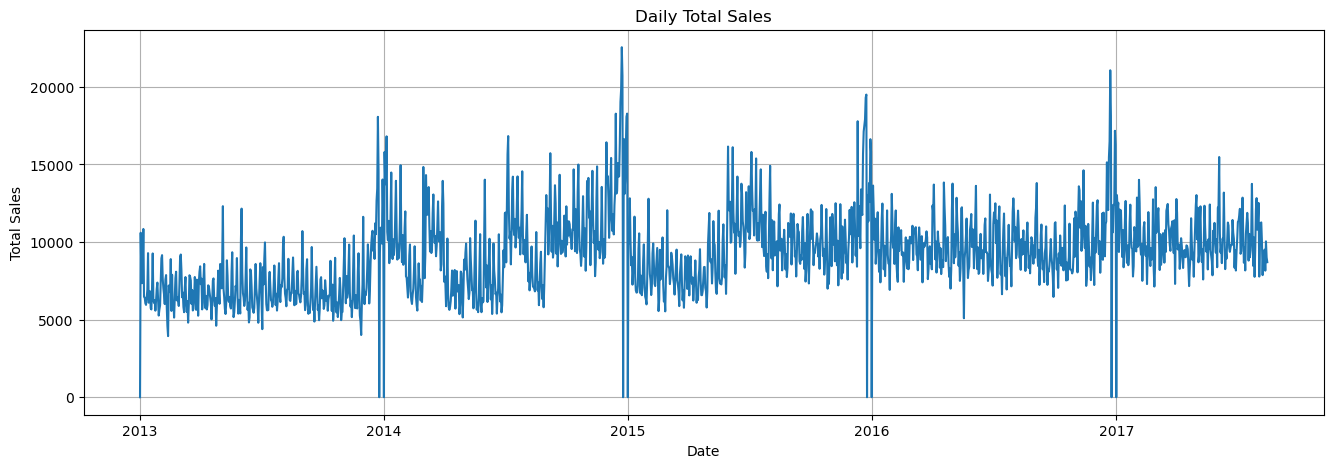

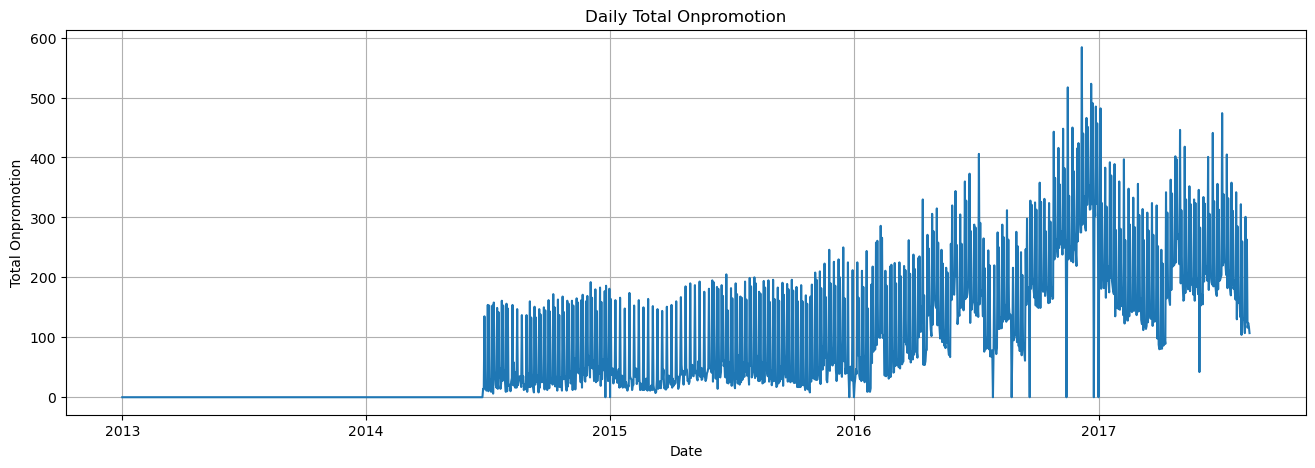

In [7]:
# Plot data
plt.figure(figsize=(16, 5))
plt.plot(df_transactions.index, df_transactions['total_sales'])
plt.title('Daily Total Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

plt.figure(figsize=(16, 5))
plt.plot(df_transactions.index, df_transactions['total_onpromotion'])
plt.title('Daily Total Onpromotion')
plt.xlabel('Date')
plt.ylabel('Total Onpromotion')
plt.grid(True)
plt.show()

In [8]:
# Cek tanggal penjualan yang mengandung outlier besar
df_transactions[df_transactions['total_sales'] < 10]

,total_sales,total_onpromotion
date,,
2013-01-01,0.0,0
2013-12-25,0.0,0
2014-01-01,0.0,0
2014-12-25,0.0,0
2015-01-01,0.0,0
2015-12-25,0.0,0
2016-01-01,0.0,0
2016-12-25,0.0,0
2017-01-01,0.0,0


In [9]:
# Buang data penjualan ketika toko tutup
df_transactions = df_transactions[df_transactions['total_sales'] > 0]

### Kesimpulan

Seasonal plot menunjukkan pola teratur. Hal ini menunjukkan penjualan harian memiliki cycle 7 hari.

Namun, residual mengandung outlier besar - sepertinya karena toko tutup pada hari libur.

Untuk memudahkan modeling, maka data penjualan ketika toko tutup dihapus.

# Modeling

In [10]:
# Split data train, validation, dan test
n = len(df_transactions)

train_size = int(n * 0.7)
val_size = int(n * 0.1)
test_size = n - train_size - val_size

train = df_transactions.iloc[:train_size]
val = df_transactions.iloc[train_size:train_size + val_size]
test = df_transactions.iloc[train_size + val_size:]

print('Train shape\t:', train.shape)
print('Validation shape:', val.shape)
print('Test shape\t:', test.shape)

print('\nTrain period\t:', train.index.min(), 'sampai', train.index.max())
print('Val period\t:', val.index.min(), 'sampai', val.index.max())
print('Test period\t:', test.index.min(), 'sampai', test.index.max())

Train shape	: (1175, 2)
Validation shape: (167, 2)
Test shape	: (337, 2)

Train period	: 2013-01-02 00:00:00 sampai 2016-03-27 00:00:00
Val period	: 2016-03-28 00:00:00 sampai 2016-09-10 00:00:00
Test period	: 2016-09-11 00:00:00 sampai 2017-08-15 00:00:00


In [11]:
# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)

print(train_scaled.shape, val_scaled.shape, test_scaled.shape)

(1175, 2) (167, 2) (337, 2)


In [12]:
# Buat fungsi untuk membentuk sequence (sliding window)
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 7

X_train, y_train = create_sequences(train_scaled, window_size)
X_val, y_val = create_sequences(val_scaled, window_size)
X_test, y_test = create_sequences(test_scaled, window_size)

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_val shape  :', X_val.shape)
print('y_val shape  :', y_val.shape)
print('X_test shape :', X_test.shape)
print('y_test shape :', y_test.shape)

X_train shape: (1168, 7)
y_train shape: (1168,)
X_val shape  : (160, 7)
y_val shape  : (160,)
X_test shape : (330, 7)
y_test shape : (330,)


In [13]:
# Reshape ke format LSTM/GRU (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print('X_train reshaped:', X_train.shape)
print('X_val reshaped  :', X_val.shape)
print('X_test reshaped :', X_test.shape)

X_train reshaped: (1168, 7, 1)
X_val reshaped  : (160, 7, 1)
X_test reshaped : (330, 7, 1)


In [14]:
# Callback training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [15]:
# Fungsi evaluasi dan plot
def evaluate_forecast(y_true, y_pred, model_name='Model'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

    print(f'--- {model_name} ---')
    print(f'MAE  : {mae:.4f}')
    print(f'RMSE : {rmse:.4f}')
    print(f'MAPE : {mape:.4f}%')

    return mae, rmse, mape

def plot_history(history, title='Training History'):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_predictions(y_true, y_pred, title='Actual vs Predicted'):
    plt.figure(figsize=(16, 5))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(title)
    plt.xlabel('Time Step')
    plt.ylabel('Total Sales')
    plt.legend()
    plt.grid(True)
    plt.show()

def inverse_transform_values(values, scaler):
    # The scaler was fit on 2 features (sales, onpromotion)
    # We need to create a dummy array with 2 columns to satisfy the scaler
    values = values.reshape(-1, 1)
    dummy = np.zeros((len(values), 2))
    dummy[:, 0] = values[:, 0]
    return scaler.inverse_transform(dummy)[:, 0]

## Single LSTM

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0358 - mae: 0.1418 - val_loss: 0.0080 - val_mae: 0.0722 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0117 - mae: 0.0835 - val_loss: 0.0083 - val_mae: 0.0734 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0105 - mae: 0.0798 - val_loss: 0.0083 - val_mae: 0.0728 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0100 - mae: 0.0772 - val_loss: 0.0085 - val_mae: 0.0733 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0098 - mae: 0.0760 - val_loss: 0.0084 - val_mae: 0.0728 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0096 - mae: 0.0755 - val_loss: 0.0084 - val_mae: 0.0713 - learning_rate: 0.0010
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0096 - mae: 0.0751 - val_loss: 0.0086 - val_mae: 0.0715 - learning_rate: 5.0000e-04
Epoch 8/

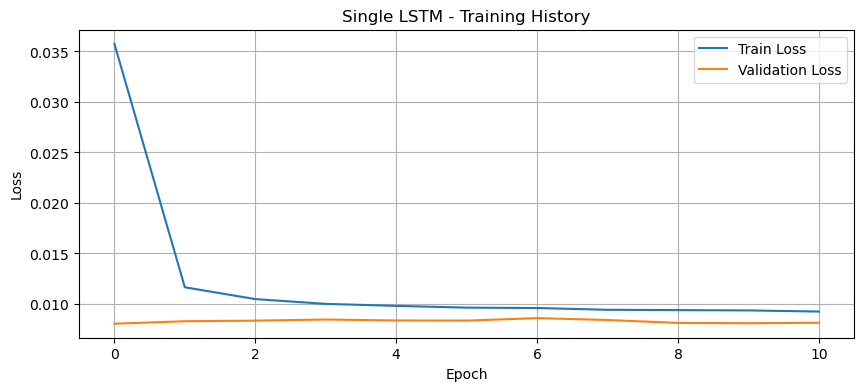

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
--- Single LSTM ---
MAE  : 1284.7920
RMSE : 1713.0583
MAPE : 12.4428%


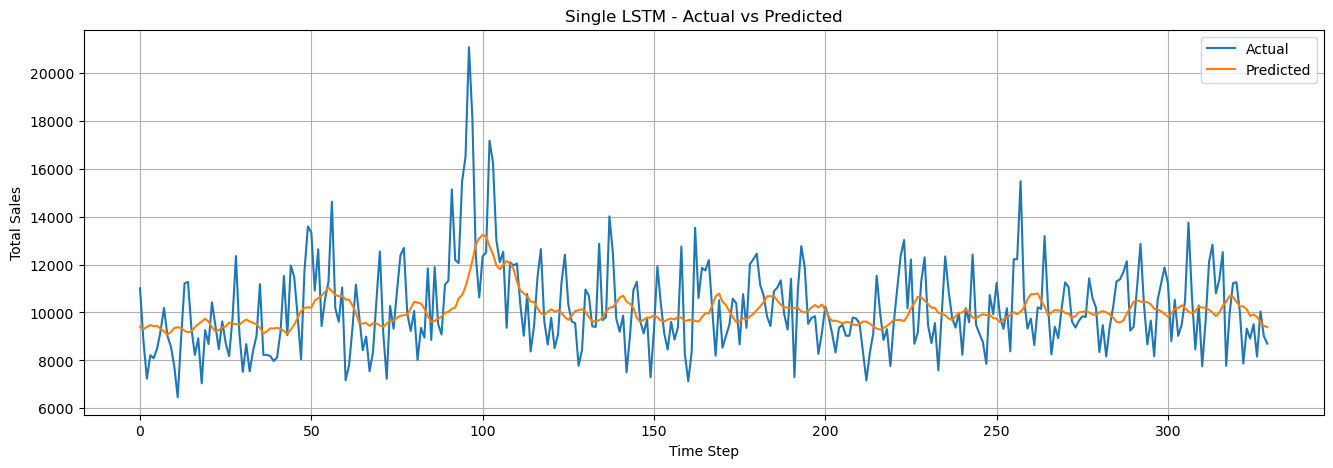

In [16]:
# Build model
def build_single_lstm(window_size):
    model = Sequential([
        tf.keras.Input(shape=(window_size, 1)),
        LSTM(50),
        Dense(1)
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

# Train
single_lstm = build_single_lstm(window_size)
single_lstm.summary()

history_single_lstm = single_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot
plot_history(history_single_lstm, 'Single LSTM - Training History')

# Predict
single_lstm_pred = single_lstm.predict(X_test)
y_test_actual = inverse_transform_values(y_test, scaler)
single_lstm_pred_actual = inverse_transform_values(single_lstm_pred.flatten(), scaler)

# Evaluate
single_lstm_metrics = evaluate_forecast(
    y_test_actual,
    single_lstm_pred_actual,
    'Single LSTM'
)

# Plot predictions
plot_predictions(y_test_actual, single_lstm_pred_actual, 'Single LSTM - Actual vs Predicted')

## Stacked LSTM

c:\Users\Bagas\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 7, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0220 - mae: 0.1104 - val_loss: 0.0083 - val_mae: 0.0701 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0103 - mae: 0.0785 - val_loss: 0.0082 - val_mae: 0.0716 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0097 - mae: 0.0749 - val_loss: 0.0084 - val_mae: 0.0733 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0097 - mae: 0.0755 - val_loss: 0.0087 - val_mae: 0.0716 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0099 - mae: 0.0750 - val_loss: 0.0089 - val_mae: 0.0721 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0098 - mae: 0.0746 - val_loss: 0.0084 - val_mae: 0.0734 - learning_rate: 5.0000e-04
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0096 - mae: 0.0744 - val_loss: 0.0082 - val_mae: 0.0708 - learning_rate: 5.0000e-04
Epoc

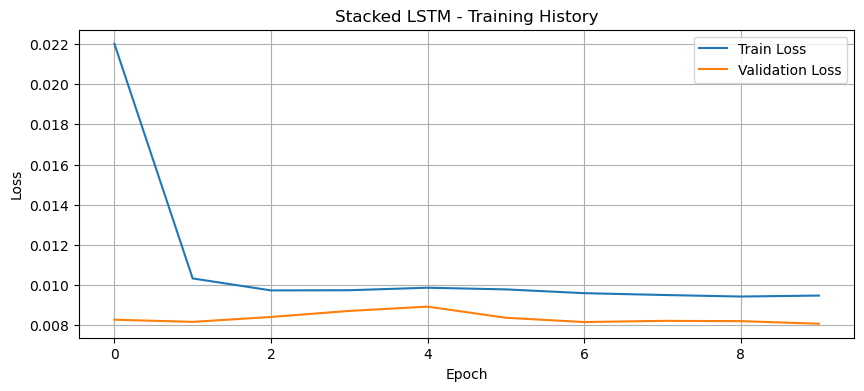

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
--- Stacked LSTM ---
MAE  : 1291.7750
RMSE : 1801.0632
MAPE : 11.9054%


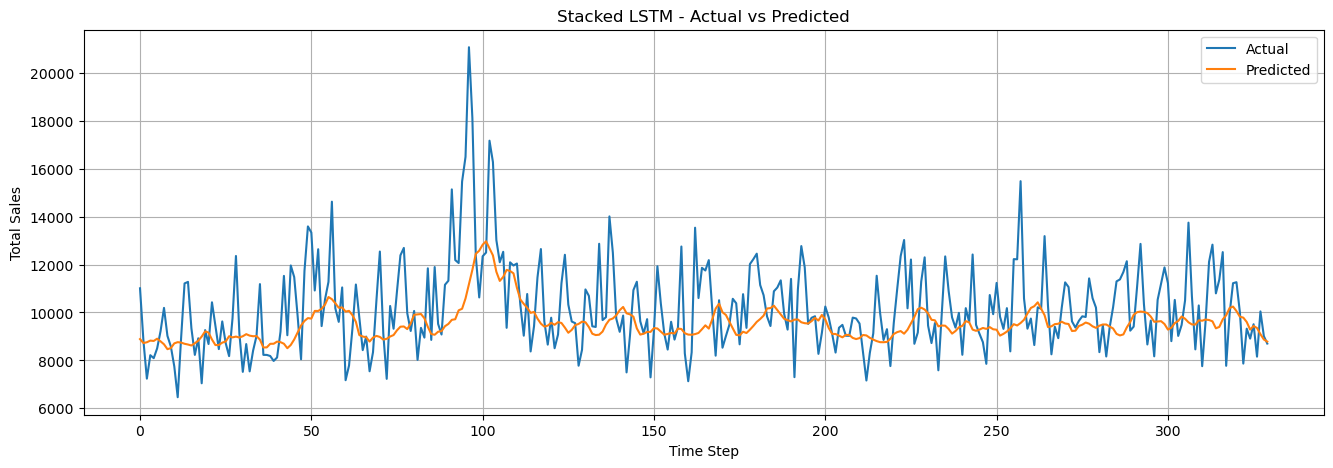

In [17]:
# Build model
def build_stacked_lstm(window_size):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
        LSTM(32),
        Dense(1)
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

# Train
stacked_lstm = build_stacked_lstm(window_size)
stacked_lstm.summary()

history_stacked_lstm = stacked_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot
plot_history(history_stacked_lstm, 'Stacked LSTM - Training History')

# Predict
stacked_lstm_pred = stacked_lstm.predict(X_test)
stacked_lstm_pred_actual = inverse_transform_values(stacked_lstm_pred.flatten(), scaler)

# Evaluate
stacked_lstm_metrics = evaluate_forecast(
    y_test_actual,
    stacked_lstm_pred_actual,
    'Stacked LSTM'
)

# Plot predictions
plot_predictions(y_test_actual, stacked_lstm_pred_actual, 'Stacked LSTM - Actual vs Predicted')

## Bidirectional LSTM

c:\Users\Bagas\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100)            │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,901 (81.64 KB)

 Trainable params: 20,901 (81.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0192 - mae: 0.1056 - val_loss: 0.0088 - val_mae: 0.0717 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0099 - mae: 0.0761 - val_loss: 0.0084 - val_mae: 0.0746 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0096 - mae: 0.0764 - val_loss: 0.0080 - val_mae: 0.0707 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093 - mae: 0.0741 - val_loss: 0.0080 - val_mae: 0.0698 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0092 - mae: 0.0732 - val_loss: 0.0079 - val_mae: 0.0694 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0090 - mae: 0.0727 - val_loss: 0.0078 - val_mae: 0.0702 - learning_rate: 0.0010
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0090 - mae: 0.0727 - val_loss: 0.0077 - val_mae: 0.0687 - learning_rate: 0.0010
Epoch 8/100


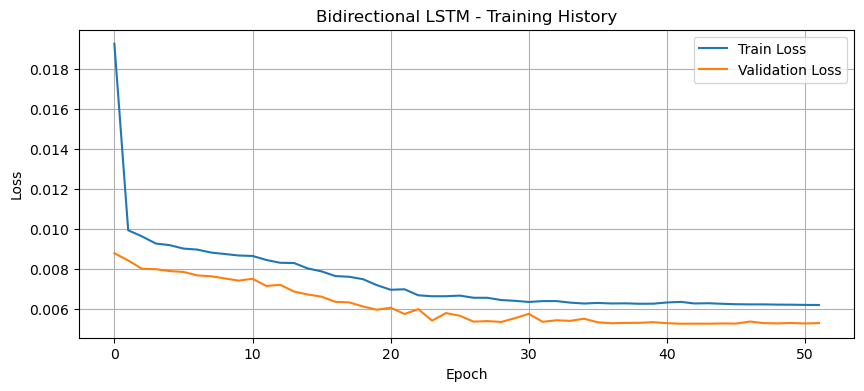

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
--- Bidirectional LSTM ---
MAE  : 1094.1494
RMSE : 1454.5415
MAPE : 10.5096%


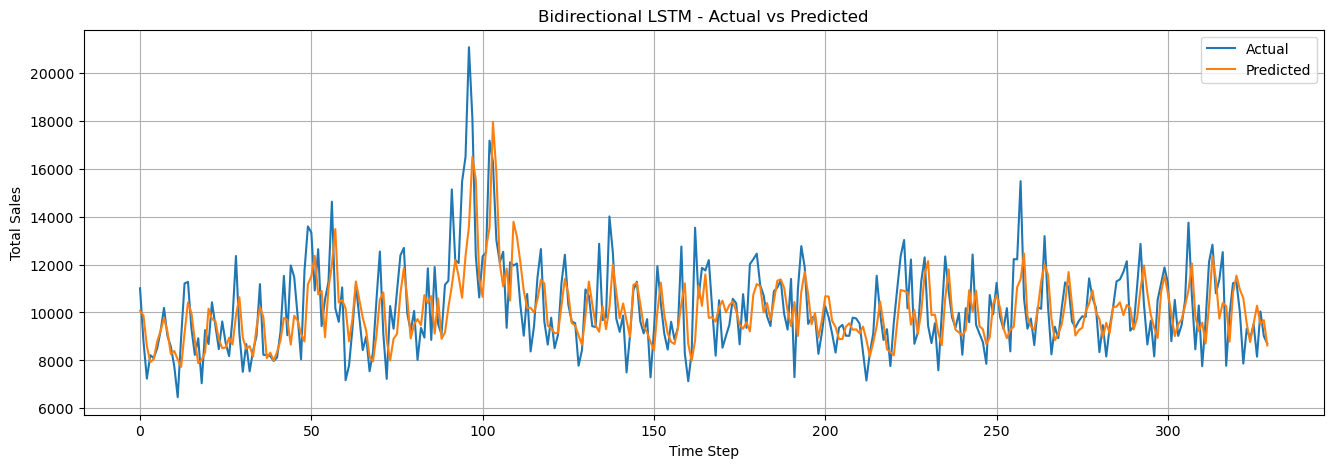

In [18]:
# Build model
def build_bidirectional_lstm(window_size):
    model = Sequential([
        Bidirectional(LSTM(50), input_shape=(window_size, 1)),
        Dense(1)
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

# Train
bidirectional_lstm = build_bidirectional_lstm(window_size)
bidirectional_lstm.summary()

history_bidirectional_lstm = bidirectional_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot
plot_history(history_bidirectional_lstm, 'Bidirectional LSTM - Training History')

# Predict
bidirectional_lstm_pred = bidirectional_lstm.predict(X_test)
bidirectional_lstm_pred_actual = inverse_transform_values(bidirectional_lstm_pred.flatten(), scaler)

# Evaluate
bidirectional_lstm_metrics = evaluate_forecast(
    y_test_actual,
    bidirectional_lstm_pred_actual,
    'Bidirectional LSTM'
)

# Plot predictions
plot_predictions(y_test_actual, bidirectional_lstm_pred_actual, 'Bidirectional LSTM - Actual vs Predicted')

## GRU

c:\Users\Bagas\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0293 - mae: 0.1319 - val_loss: 0.0092 - val_mae: 0.0731 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0118 - mae: 0.0841 - val_loss: 0.0081 - val_mae: 0.0720 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0103 - mae: 0.0801 - val_loss: 0.0083 - val_mae: 0.0723 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0096 - mae: 0.0770 - val_loss: 0.0084 - val_mae: 0.0743 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0092 - mae: 0.0755 - val_loss: 0.0082 - val_mae: 0.0732 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0090 - mae: 0.0745 - val_loss: 0.0080 - val_mae: 0.0709 - learning_rate: 5.0000e-04
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0089 - mae: 0.0737 - val_loss: 0.0081 - val_mae: 0.0698 - learning_rate: 5.0000e-04
E

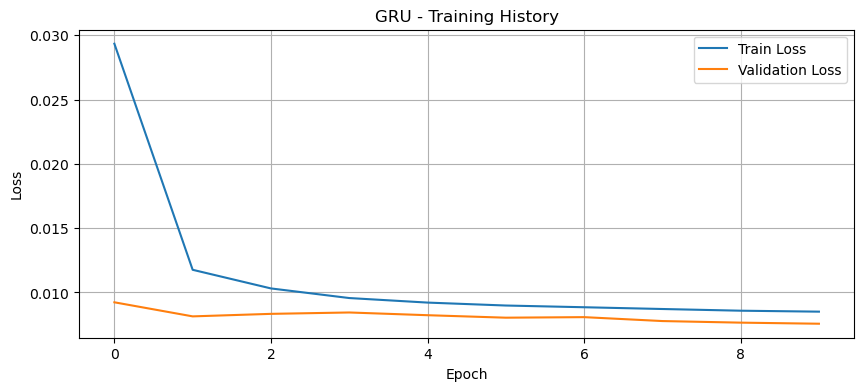

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
--- GRU ---
MAE  : 1435.6072
RMSE : 1988.7157
MAPE : 12.9411%


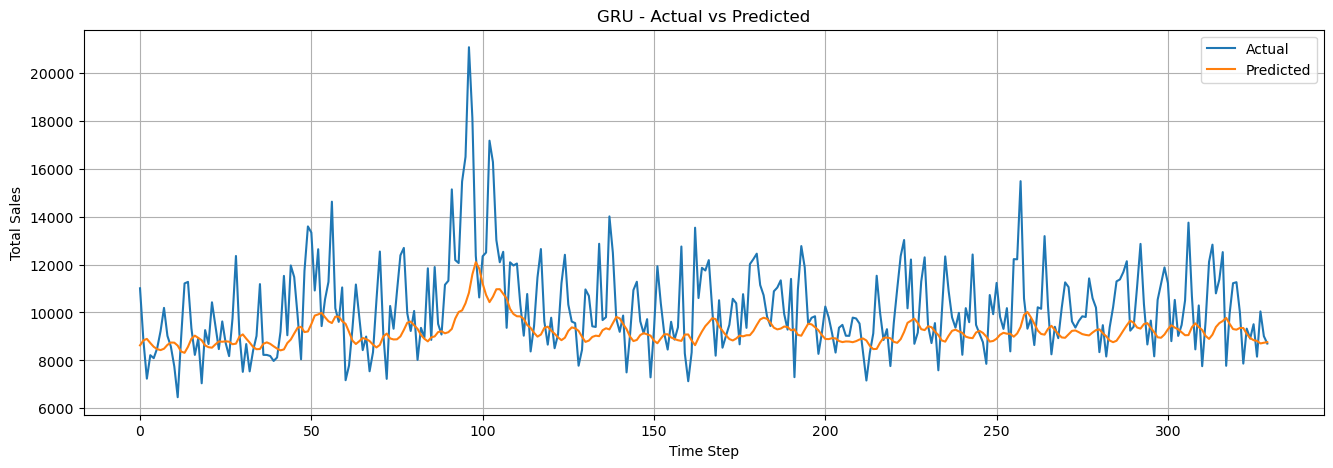

In [19]:
# Build model
def build_gru(window_size):
    model = Sequential([
        GRU(50, input_shape=(window_size, 1)),
        Dense(1)
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

# Train
gru_model = build_gru(window_size)
gru_model.summary()

history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot
plot_history(history_gru, 'GRU - Training History')

# Predict
gru_pred = gru_model.predict(X_test)
gru_pred_actual = inverse_transform_values(gru_pred.flatten(), scaler)

# Evaluate
gru_metrics = evaluate_forecast(
    y_test_actual,
    gru_pred_actual,
    'GRU'
)

# Plot predictions
plot_predictions(y_test_actual, gru_pred_actual, 'GRU - Actual vs Predicted')

## LSTM + BatchNormalization + L1/L2 Regularization

c:\Users\Bagas\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,137 (74.75 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 0.0765 - mae: 0.1636 - val_loss: 0.0510 - val_mae: 0.1360 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0447 - mae: 0.1053 - val_loss: 0.0314 - val_mae: 0.0681 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0380 - mae: 0.0913 - val_loss: 0.0287 - val_mae: 0.0693 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0342 - mae: 0.0849 - val_loss: 0.0274 - val_mae: 0.0701 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0302 - mae: 0.0783 - val_loss: 0.0276 - val_mae: 0.0781 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0296 - mae: 0.0762 - val_loss: 0.0256 - val_mae: 0.0692 - learning_rate: 5.0000e-04
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0288 - mae: 0.0761 - val_loss: 0.0256 - val_mae: 0.0721 - learning_rate: 5.0000e-0

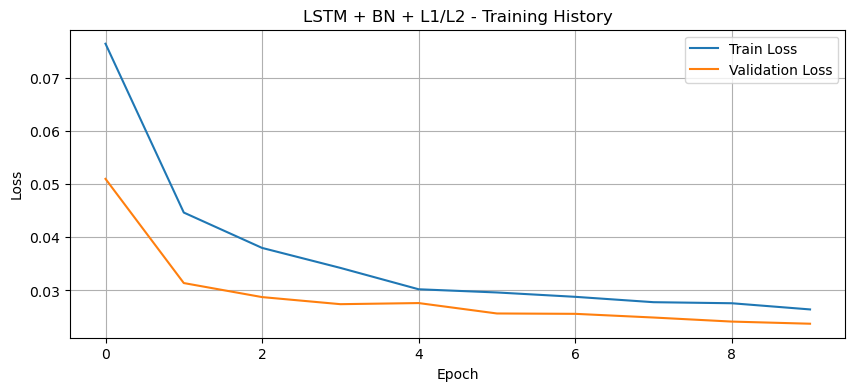

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step
--- LSTM + BatchNorm + L1/L2 ---
MAE  : 2966.8876
RMSE : 3489.5026
MAPE : 27.0955%


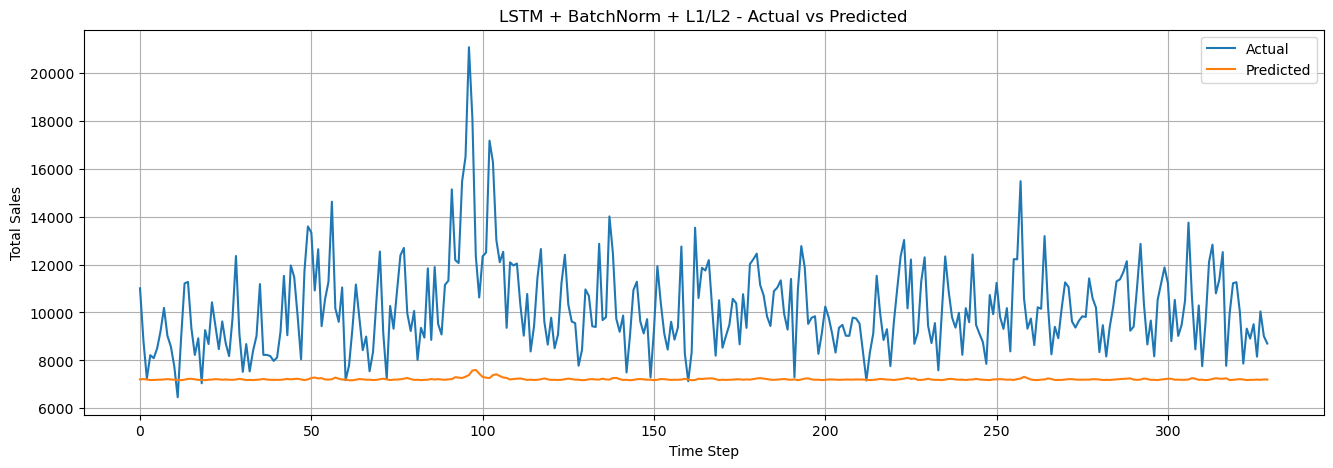

In [20]:
# Build model
def build_lstm_bn_l1l2(window_size):
    model = Sequential([
        LSTM(
            64,
            input_shape=(window_size, 1),
            kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4),
            recurrent_regularizer=l1_l2(l1=1e-5, l2=1e-4),
            bias_regularizer=l1_l2(l1=1e-5, l2=1e-4)
        ),
        BatchNormalization(),
        Dropout(0.2),
        Dense(
            32,
            activation='relu',
            kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)
        ),
        Dense(1)
    ])
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

# Train
lstm_bn_l1l2 = build_lstm_bn_l1l2(window_size)
lstm_bn_l1l2.summary()

history_lstm_bn_l1l2 = lstm_bn_l1l2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot
plot_history(history_lstm_bn_l1l2, 'LSTM + BN + L1/L2 - Training History')

# Predict
lstm_bn_l1l2_pred = lstm_bn_l1l2.predict(X_test)
lstm_bn_l1l2_pred_actual = inverse_transform_values(lstm_bn_l1l2_pred.flatten(), scaler)

# Evaluate
lstm_bn_l1l2_metrics = evaluate_forecast(
    y_test_actual,
    lstm_bn_l1l2_pred_actual,
    'LSTM + BatchNorm + L1/L2'
)

# Plot predictions
plot_predictions(y_test_actual, lstm_bn_l1l2_pred_actual, 'LSTM + BatchNorm + L1/L2 - Actual vs Predicted')

# Perbandingan Model

In [21]:
# Bandingkan semua model
comparison_dl = pd.DataFrame({
    'Model': [
        'Single LSTM',
        'Stacked LSTM',
        'Bidirectional LSTM',
        'GRU',
        'LSTM + BatchNorm + L1/L2'
    ],
    'MAE': [
        single_lstm_metrics[0],
        stacked_lstm_metrics[0],
        bidirectional_lstm_metrics[0],
        gru_metrics[0],
        lstm_bn_l1l2_metrics[0]
    ],
    'RMSE': [
        single_lstm_metrics[1],
        stacked_lstm_metrics[1],
        bidirectional_lstm_metrics[1],
        gru_metrics[1],
        lstm_bn_l1l2_metrics[1]
    ],
    'MAPE': [
        single_lstm_metrics[2],
        stacked_lstm_metrics[2],
        bidirectional_lstm_metrics[2],
        gru_metrics[2],
        lstm_bn_l1l2_metrics[2]
    ]
})

comparison_dl = comparison_dl.sort_values(by='RMSE').reset_index(drop=True)
display(comparison_dl)

print('\nBest deep learning model based on RMSE:')
print(comparison_dl.iloc[0])

,Model,MAE,RMSE,MAPE
0,Bidirectional LSTM,1094.149356,1454.541476,10.509610
1,Single LSTM,1284.792009,1713.058327,12.442766
2,Stacked LSTM,1291.774980,1801.063215,11.905397
3,GRU,1435.607155,1988.715698,12.941132
4,LSTM + BatchNorm + L1/L2,2966.887618,3489.502578,27.095504



Best deep learning model based on RMSE:
Model    Bidirectional LSTM
MAE             1094.149356
RMSE            1454.541476
MAPE               10.50961
Name: 0, dtype: object


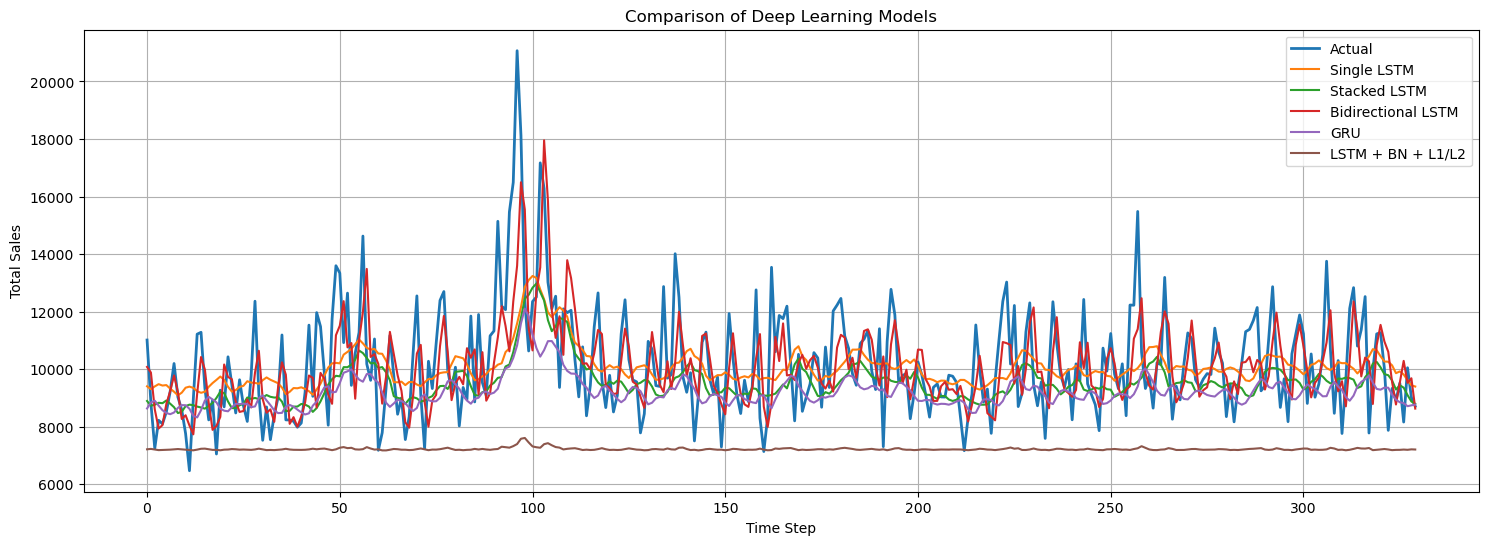

In [22]:
# Plot semua prediksi sekaligus
plt.figure(figsize=(18, 6))
plt.plot(y_test_actual, label='Actual', linewidth=2)
plt.plot(single_lstm_pred_actual, label='Single LSTM')
plt.plot(stacked_lstm_pred_actual, label='Stacked LSTM')
plt.plot(bidirectional_lstm_pred_actual, label='Bidirectional LSTM')
plt.plot(gru_pred_actual, label='GRU')
plt.plot(lstm_bn_l1l2_pred_actual, label='LSTM + BN + L1/L2')

plt.title('Comparison of Deep Learning Models')
plt.xlabel('Time Step')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
# plt.savefig('Comparison of Deep Learning Models.png', dpi=300, bbox_inches='tight')
plt.show()

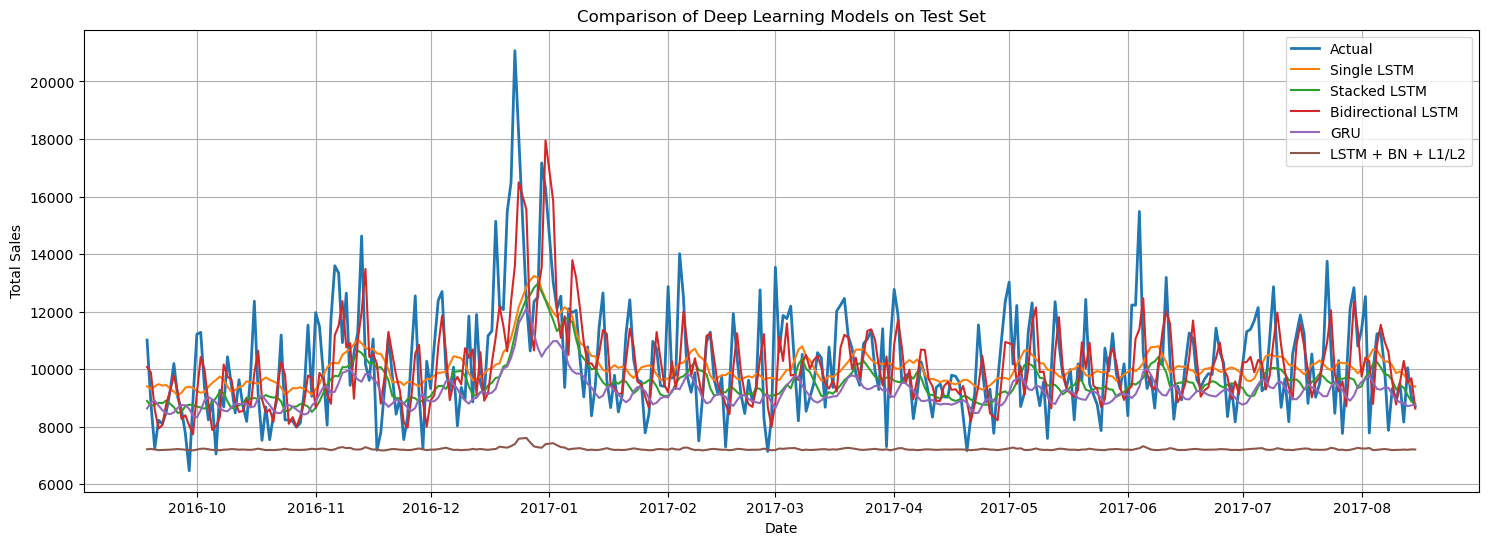

In [23]:
# Plot dengan tanggal test asli
test_dates = test.index[window_size:]

plt.figure(figsize=(18, 6))
plt.plot(test_dates, y_test_actual, label='Actual', linewidth=2)
plt.plot(test_dates, single_lstm_pred_actual, label='Single LSTM')
plt.plot(test_dates, stacked_lstm_pred_actual, label='Stacked LSTM')
plt.plot(test_dates, bidirectional_lstm_pred_actual, label='Bidirectional LSTM')
plt.plot(test_dates, gru_pred_actual, label='GRU')
plt.plot(test_dates, lstm_bn_l1l2_pred_actual, label='LSTM + BN + L1/L2')

plt.title('Comparison of Deep Learning Models on Test Set')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

# Prediksi future 30 hari ke depan

In [ ]:
def forecast_future(model, last_window, future_steps, scaler):
    future_predictions = []
    current_window = last_window.copy()

    for _ in range(future_steps):
        # Prediksi nilai berikutnya (skala 0-1)
        pred = model.predict(current_window, verbose=0)[0, 0]
        future_predictions.append(pred)

        # Update window: hapus data tertua, masukkan prediksi terbaru
        pred_for_window = np.array(pred).reshape(1, 1, 1)
        current_window = np.concatenate((current_window[:, 1:, :], pred_for_window), axis=1)

    # Balikkan ke skala aslinya
    future_predictions = np.array(future_predictions).reshape(-1, 1)
    future_predictions_actual = scaler.inverse_transform(future_predictions).flatten()

    return future_predictions_actual

# Gunakan scaler khusus sales saja agar tidak bentrok jumlah fitur
scaler_sales_only = MinMaxScaler(feature_range=(0, 1))
scaler_sales_only.fit(df_transactions[['total_sales']].iloc[:train_size])

all_scaled_sales = scaler_sales_only.transform(df_transactions[['total_sales']])
last_window = all_scaled_sales[-window_size:].reshape(1, window_size, 1)

future_steps = 30
future_pred_30 = forecast_future(single_lstm, last_window, future_steps, scaler_sales_only)

future_dates = pd.date_range(
    start=df_transactions.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq='D'
)

future_forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast_total_sales': future_pred_30
})

display(future_forecast_df.head())

,date,forecast_total_sales
0,2017-08-16,8971.810547
1,2017-08-17,8963.365234
2,2017-08-18,9074.319336
3,2017-08-19,8826.353516
4,2017-08-20,9284.939453


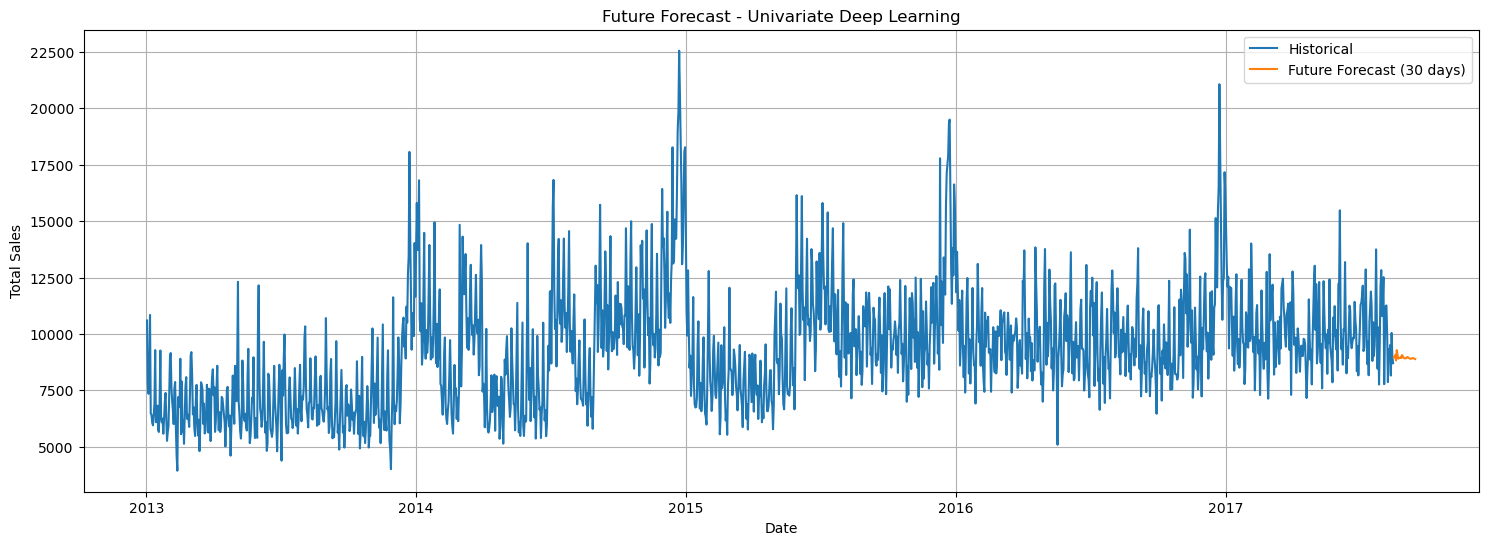

In [25]:
# Plot
plt.figure(figsize=(18, 6))
plt.plot(df_transactions.index, df_transactions['total_sales'], label='Historical')
plt.plot(future_dates, future_pred_30, label='Future Forecast (30 days)')
plt.title('Future Forecast - Univariate Deep Learning')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()